In [59]:
%pip install tensorflow
%pip install scikit-learn
%pip install Pillow
%pip install tqdm
%pip install nltk
%pip install matplotlib
%pip install numpy
%pip install seaborn

from pathlib import Path
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add, BatchNormalization, concatenate
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm_notebook
from collections import Counter
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction, sentence_bleu
from nltk.translate.meteor_score import meteor_score
from tqdm import tqdm
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import nltk
import tensorflow as tf
import textwrap

# Define the base directory and paths to images and captions
BASE_DIR = Path.cwd()
images = BASE_DIR / "archive" / "Images"
captions = BASE_DIR / "archive" / "captions.txt"
nltk.download('wordnet')
nltk.download('omw-1.4')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\colin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\colin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Data Loading (Captions & Images)

Loads raw caption data from a file and retrieves image file names from a directory.

In [2]:
# Function to load captions from the text file
def load_captions(file_path):
    with open(file_path, 'r') as f:
        captions = f.readlines()
        captions = [caption.lower().strip() for caption in captions[1:]]
    return captions

# Function to load image file names from the specified directory
def load_images(image_path):
    return [f for f in os.listdir(image_path) if f.endswith(('.png', '.jpg', '.jpeg'))]

In [3]:
captions = load_captions(captions)
images = load_images(images)
print(captions[:15:3])
print(images[:15])
print("Captions loaded:", len(captions))
print("Images found:", len(images))
print("Sample captions:", captions[:5])
print("Sample images:", images[:5])

['1000268201_693b08cb0e.jpg,a child in a pink dress is climbing up a set of stairs in an entry way .', '1000268201_693b08cb0e.jpg,a little girl climbing the stairs to her playhouse .', '1001773457_577c3a7d70.jpg,a black dog and a tri-colored dog playing with each other on the road .', '1001773457_577c3a7d70.jpg,two dogs on pavement moving toward each other .', '1002674143_1b742ab4b8.jpg,a small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it .']
['1000268201_693b08cb0e.jpg', '1001773457_577c3a7d70.jpg', '1002674143_1b742ab4b8.jpg', '1003163366_44323f5815.jpg', '1007129816_e794419615.jpg', '1007320043_627395c3d8.jpg', '1009434119_febe49276a.jpg', '1012212859_01547e3f17.jpg', '1015118661_980735411b.jpg', '1015584366_dfcec3c85a.jpg', '101654506_8eb26cfb60.jpg', '101669240_b2d3e7f17b.jpg', '1016887272_03199f49c4.jpg', '1019077836_6fc9b15408.jpg', '1019604187_d087bf9a5f.jpg']
Captions loaded: 40455
Images found: 8091
Sample captions: ['1000268201_69

## Caption Cleaning & Preprocessing

Cleans raw caption text by removing noise and standardizing formatting for model training.

In [4]:
# Clean up captions by removing newlines and extra spaces
def clean_captions(captions):
    cleaned_captions = []
    for caption in captions:
        cleaned_caption = caption.split(',')[1]
        cleaned_caption = re.sub(r'[^\w\s]', '', cleaned_caption)
        cleaned_caption = re.sub(r'\d+', '', cleaned_caption)
        cleaned_caption = re.sub(r'\s+', ' ', cleaned_caption).strip()
        cleaned_captions.append(cleaned_caption)
    return cleaned_captions

cleaned_captions = clean_captions(captions)
print(f"Cleaned Captions: {cleaned_captions[:20:2]}")

Cleaned Captions: ['a child in a pink dress is climbing up a set of stairs in an entry way', 'a little girl climbing into a wooden playhouse', 'a little girl in a pink dress going into a wooden cabin', 'a black dog and a tricolored dog playing with each other on the road', 'two dogs of different breeds looking at each other on the road', 'a little girl covered in paint sits in front of a painted rainbow with her hands in a bowl', 'a small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it', 'young girl with pigtails painting outside in the grass', 'a man lays on the bench to which a white dog is also tied', 'a shirtless man lies on a park bench with his dog']


## Caption Formatting with Start/End Tokens

Creates formatted caption strings by pairing image IDs with cleaned captions and adding sequence boundary tokens.

### Purpose

- Associate each caption with its corresponding image ID  
- Add `"start"` and `"end"` tokens for sequence modeling  
- Prepare captions for tokenization and training  


In [5]:
def create_caption_ids(captions, cleaned_captions):
    captions_IDS = []
    for i in range(len(cleaned_captions)):
        item = captions[i].split(',')[0]+'\t' + 'start ' + cleaned_captions[i] + ' end\n'
        captions_IDS.append(item)
    return captions_IDS

captions_IDS = create_caption_ids(captions, cleaned_captions)

## Caption Visualization

Displays sample images along with their associated captions from the dataset.

### Parameters
- `captions_IDS`: list of image-caption pairs (`image_id \t caption`)
- `num_samples`: number of images to display  


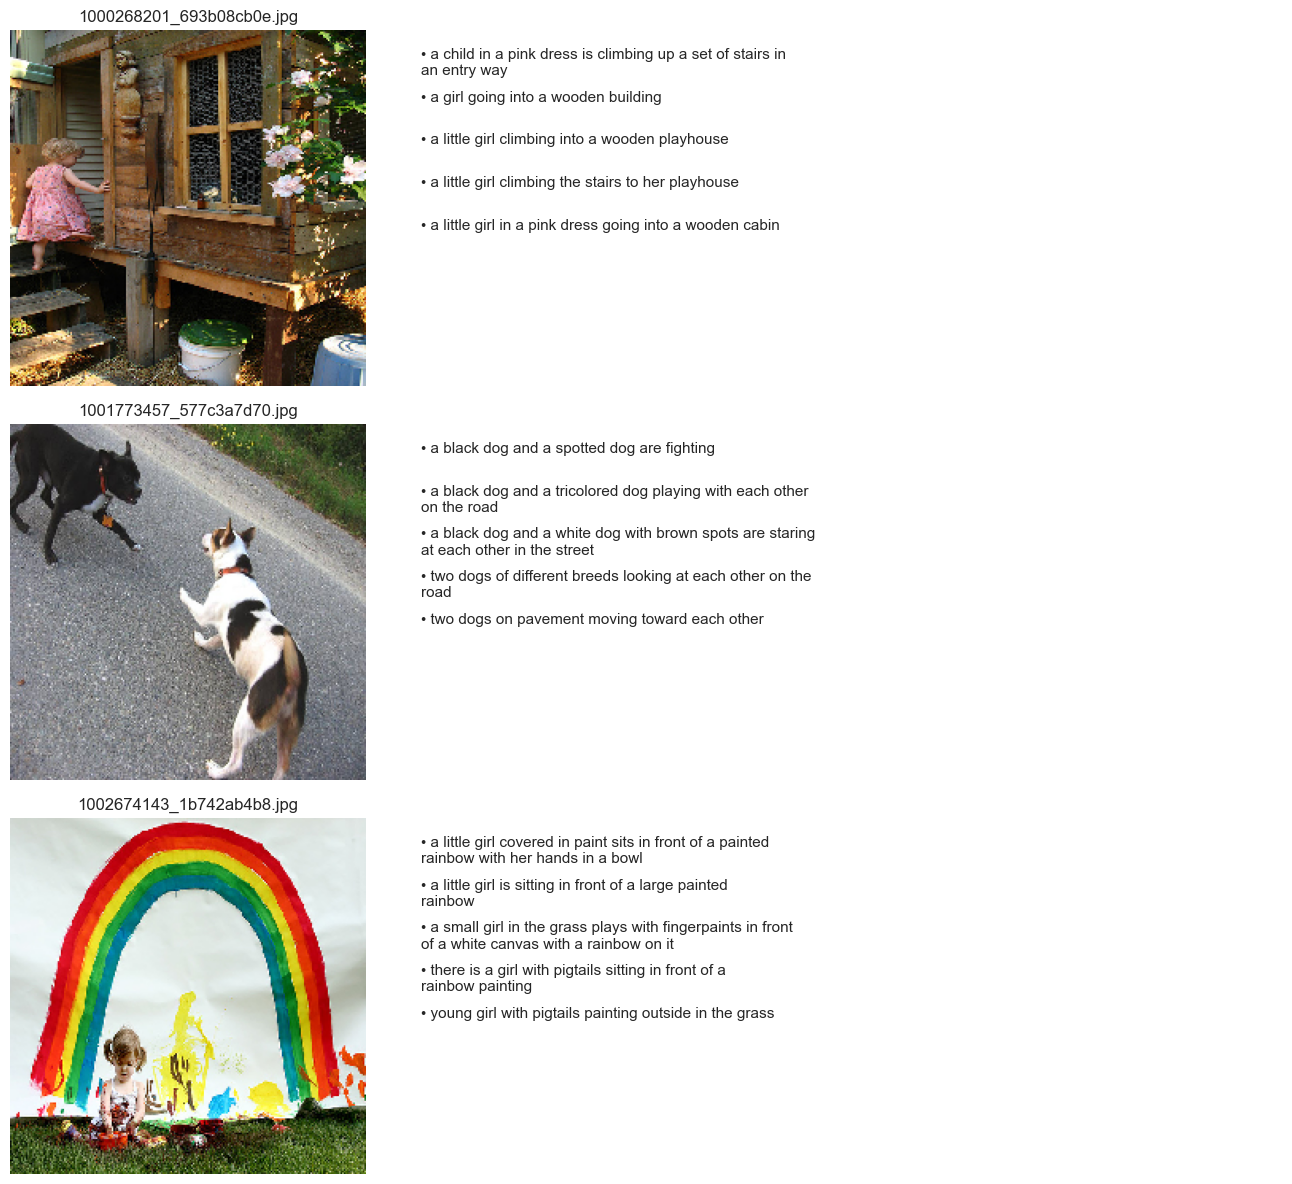

In [72]:
def visualize_captions(captions_IDS, num_samples=5):
    # Group captions by image
    caption_dict = {}
    for caption in captions_IDS:
        image_id, caption_text = caption.split('\t')
        clean_caption = ' '.join([
            word for word in caption_text.split()
            if word not in ['start', 'end']
        ])

        caption_dict.setdefault(image_id, []).append(clean_caption)

    # Sample images
    image_items = list(caption_dict.items())
    selected = image_items[:num_samples]

    fig, axes = plt.subplots(
        num_samples,
        2,
        figsize=(14, 4 * num_samples),
        gridspec_kw={'width_ratios': [1, 1.6]}
    )

    if num_samples == 1:
        axes = np.array([axes])

    for row, (image_id, captions) in enumerate(selected):
        # Load image
        img = image.load_img(
            str(BASE_DIR / "archive" / "Images" / image_id),
            target_size=(224, 224)
        )

        # LEFT: image
        ax_img = axes[row, 0]
        ax_img.imshow(img)
        ax_img.axis("off")
        ax_img.set_title(image_id, fontsize=12)

        # RIGHT: captions
        ax_text = axes[row, 1]
        ax_text.axis("off")

        y = 0.95
        for cap in captions:
            wrapped = textwrap.fill(f"• {cap}", width=60)
            ax_text.text(0, y, wrapped, fontsize=11, va='top')
            y -= 0.12

    plt.tight_layout()
    plt.show()

visualize_captions(captions_IDS, num_samples=3)

## Text Tokenization & Vocabulary Creation

Processes caption text and builds a vocabulary for the model.

In [7]:
all_captions = [caption.split('\t')[1].strip() for caption in captions_IDS]
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1
print(f"Vocabulary Size: {vocab_size}")

Vocabulary Size: 8586


## Dataset Splitting (Train / Validation / Test)

Splits the dataset into:
- Training set (80%)  
- Validation set (10%)  
- Test set (10%)  


In [8]:
def split_dataset(images, captions_IDS):
    train_caption_id, temp_caption_id = train_test_split(images, test_size=0.2, random_state=42)
    val_captions_id, test_captions_id = train_test_split(temp_caption_id, test_size=0.5, random_state=42)
    train_caption, val_caption, test_caption = [], [], []
    for caption in captions_IDS: 
        image_id, _ = caption.split('\t', 1)
        if image_id in train_caption_id:
            train_caption.append(caption)
        elif image_id in val_captions_id:
            val_caption.append(caption)
        elif image_id in test_captions_id:
            test_caption.append(caption)
    return train_caption, val_caption, test_caption, train_caption_id, val_captions_id, test_captions_id

train_captions, val_captions, test_captions, train_caption_id, val_captions_id, test_captions_id = split_dataset(images, captions_IDS)
# print(f"Total captions: {len(images)}")
print(f"Sample training caption: {train_captions[0]}")
print(f"Sample validation caption: {val_captions[0]}")
print(f"Sample test caption: {test_captions[0]}")

Sample training caption: 1000268201_693b08cb0e.jpg	start a child in a pink dress is climbing up a set of stairs in an entry way end

Sample validation caption: 104136873_5b5d41be75.jpg	start people sit on the mountainside and check out the view end

Sample test caption: 1022454428_b6b660a67b.jpg	start a couple and an infant end



## Image Feature Extraction (ResNet50)

Extracts a fixed-length feature vector from an image using a pretrained **ResNet50** model.

### Purpose

- Convert raw images into **numerical feature vectors**  
- Use pretrained CNN knowledge (ImageNet)  
- Avoid training a CNN from scratch  


In [9]:
# Image feature extraction using a pretrained model (ResNet50)
# include_top=False removes the classifier
# pooling='avg' gives a single 2048-d feature vector for each image
resnet_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
# Function to extract features for a single image
def extract_image_features(image_path, model):
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    features = model(img_array, training=False).numpy()  
    return features.flatten()

extract_image_features(str(BASE_DIR / "archive" / "Images" / images[0]), resnet_model)

array([0.0653655 , 0.16782731, 0.3251846 , ..., 0.05111521, 0.3281792 ,
       1.0043341 ], shape=(2048,), dtype=float32)

## Feature Extraction & Dataset Split

Extracts CNN image features and splits them into corresponding data sets.

### Purpose

- Convert raw images into **feature vectors** using a pretrained CNN  
- Organize features into train/validation/test sets  
- Prepare data for efficient model training  


In [10]:
# Splitting the dataset into training, validation and test sets
# We will use an 80-10-10 split for training, validation and testing respectively
train_image_embeddings, val_image_embeddings, test_image_embeddings = {}, {}, {}
# Function to extract features for the entire dataset
def extract_features_for_dataset(image_path, model, train_captions_id, val_captions_id, test_captions_id, train_image_embeddings, val_image_embeddings, test_image_embeddings):
    pbar = tqdm(total=len(image_path), desc="Extracting image features", ncols =80)
    for image_id in image_path:
        image_embedding = extract_image_features(str(BASE_DIR / "archive" / "Images" / image_id), model)
        if image_id in train_captions_id:
            train_image_embeddings[image_id] = image_embedding.flatten()
        elif image_id in val_captions_id:
            val_image_embeddings[image_id] = image_embedding.flatten()
        elif image_id in test_captions_id:
            test_image_embeddings[image_id] = image_embedding.flatten()
        pbar.update(1)
    pbar.close()
extract_features_for_dataset(images, resnet_model, train_caption_id, val_captions_id, test_captions_id, train_image_embeddings, val_image_embeddings, test_image_embeddings)
print(f"Extracted image features for training set: {len(train_image_embeddings)}")
print(f"Extracted image features for validation set: {len(val_image_embeddings)}")
print(f"Extracted image features for test set: {len(test_image_embeddings)}")

Extracting image features: 100%|████████████| 8091/8091 [29:28<00:00,  4.57it/s]

Extracted image features for training set: 6472
Extracted image features for validation set: 809
Extracted image features for test set: 810


## Data Generator for Image Captioning

Generates training data batches for the captioning model by converting
image–caption pairs into input-output sequences.

### Workflow

1. **Shuffle data**
   - Randomizes image order each epoch  

2. **Batch processing**
   - Processes captions in chunks of size `batch_size`  

3. **Tokenization**
   - Converts caption text into integer sequences  

4. **Sequence splitting**
   - Each caption:
     ```text
     "start a dog runs end"
     ```
     becomes:
     ```text
     [start] → a  
     [start a] → dog  
     [start a dog] → runs  
     ```

5. **Padding**
   - Ensures all sequences have fixed length  

6. **One-hot encoding**
   - Converts target word into vector form  

7. **Yield batch**
   - Returns:
     ```text
     (image_features, input_sequence) → next_word
     ```

In [11]:
def data_generator(captions, image_embeddings, tokenizer, max_caption_length, batch_size):
    num_samples = len(captions)
    image_ids = list(image_embeddings.keys())
    while True:
        np.random.shuffle(image_ids) # shuffle captions
        for start in range(0, num_samples, batch_size):
            end = min(start + batch_size, num_samples)
            x_images, x_captions, target = [], [], []
            for caption in captions[start:end]:
                image_id, caption_text = caption.split('\t')
                caption_text = caption_text.strip('\n')
                seq = tokenizer.texts_to_sequences([caption_text])[0] # convering the caption text to a sequence of intergs
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i] # split the sequence into input and output
                    in_seq = pad_sequences([in_seq], maxlen=max_caption_length)[0] # pad the input sequence to a fixed length
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0] # convert the output sequence to one-hot encoding
                    x_images.append(image_embeddings[image_id])
                    x_captions.append(in_seq)
                    target.append(out_seq)
            yield (np.array(x_images), np.array(x_captions)), np.array(target) # yield the batch of data as a tuple of input and output

max_caption_length = max(len(caption.split()) for caption in cleaned_captions) + 2
cnn_output_dim = resnet_model.output_shape[1] # 2048

batch_size_train = 270
batch_size_val = 150

output_signature = (
    (
        tf.TensorSpec(shape=(None, cnn_output_dim), dtype=tf.float32),
        tf.TensorSpec(shape=(None, max_caption_length), dtype=tf.int32)
    ),
    tf.TensorSpec(shape=(None, vocab_size), dtype=tf.float32)
)

train_data_generator = tf.data.Dataset.from_generator(
    lambda: data_generator(train_captions, train_image_embeddings, tokenizer, max_caption_length, batch_size_train),
    output_signature=output_signature
)
val_data_generator = tf.data.Dataset.from_generator(
    lambda: data_generator(val_captions, val_image_embeddings, tokenizer, max_caption_length, batch_size_val),
    output_signature=output_signature
)

print(train_data_generator)
print(val_data_generator)

<_FlatMapDataset element_spec=((TensorSpec(shape=(None, 2048), dtype=tf.float32, name=None), TensorSpec(shape=(None, 35), dtype=tf.int32, name=None)), TensorSpec(shape=(None, 8586), dtype=tf.float32, name=None))>
<_FlatMapDataset element_spec=((TensorSpec(shape=(None, 2048), dtype=tf.float32, name=None), TensorSpec(shape=(None, 35), dtype=tf.int32, name=None)), TensorSpec(shape=(None, 8586), dtype=tf.float32, name=None))>


## Image Captioning Model (CNN + LSTM)

Builds a neural network that generates image captions by combining:
- Visual features from a CNN  
- Sequential language modeling using an LSTM  

### Architecture Overview

The model has **two input branches**:

1. **Image Branch**
   - Input: precomputed CNN feature vector  
   - Batch normalization → Dense layer → Dropout  
   - Learns a compact visual representation  

2. **Caption Branch**
   - Input: tokenized caption sequence  
   - Embedding layer → LSTM  
   - Learns contextual language representation  

3. **Fusion + Decoder**
   - Combines image + caption features using concatenation  
   - Passes through Dense + Dropout layers  
   - Outputs probability distribution over vocabulary  

In [43]:
def build_model(cnn_output_dim, max_caption_length, vocab_size):
    input_image = Input(shape=(cnn_output_dim,) , name='image_input')
    input_caption = Input(shape=(max_caption_length,), name='caption_input')
    # Image branch
    img = BatchNormalization()(input_image)
    img = Dense(256, activation='relu')(img)
    img = Dropout(0.5)(img)

    # Caption branch
    cap = Embedding(vocab_size, 256, mask_zero=True)(input_caption)
    cap = LSTM(256, dropout=0.3, recurrent_dropout=0.3)(cap)

    # Combine image + caption
    x = concatenate([img, cap])
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(vocab_size, activation='softmax', name='output')(x)
    model = Model(inputs=[input_image, input_caption], outputs=outputs, name='Image_Caption_Generator')
    return model

captain_model = build_model(cnn_output_dim, max_caption_length, vocab_size)
optimzer = Adam(learning_rate=0.001, clipnorm=1.0)
captain_model.compile(loss='categorical_crossentropy', optimizer=optimzer)
captain_model.summary()

Model: "Image_Caption_Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2048)      │      8,192 │ image_input[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_input       │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 35, 256)   │  2,198,016 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 35)        │          0 │ caption_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 256)       │    525,312 │ embedding_2[0][0… │
│                     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 512)       │          0 │ dropout_2[0][0],  │
│ (Concatenate)       │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │    131,328 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 8586)      │  2,206,602 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,593,994 (21.34 MB)

 Trainable params: 5,589,898 (21.32 MB)

 Non-trainable params: 4,096 (16.00 KB)

## Model Training with Callbacks

Trains the image captioning model using **early stopping** and **adaptive learning rate scheduling** to improve performance and prevent overfitting.

### Key Components

- **EarlyStopping**
  - Monitors `val_loss`
  - Stops training if no improvement for 3 epochs
  - Restores the best model weights

- **ReduceLROnPlateau**
  - Monitors `val_loss`
  - Reduces learning rate by 50% if performance plateaus
  - Helps fine-tune the model in later stages


### Training Process

- Uses data generators for efficient batching  
- Computes steps per epoch based on dataset size  
- Trains for up to 20 epochs (may stop early)


In [44]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
history = captain_model.fit(train_data_generator, 
                            steps_per_epoch=len(train_captions) // batch_size_train, 
                            validation_data=val_data_generator, 
                            validation_steps=len(val_captions) // batch_size_val, 
                            epochs=20, 
                            callbacks=[early_stopping, reduce_lr])

Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - loss: 5.4151 - val_loss: 4.4776 - learning_rate: 0.0010
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - loss: 4.1519 - val_loss: 3.8061 - learning_rate: 0.0010
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - loss: 3.7351 - val_loss: 3.5593 - learning_rate: 0.0010
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - loss: 3.5017 - val_loss: 3.4199 - learning_rate: 0.0010
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - loss: 3.3416 - val_loss: 3.3259 - learning_rate: 0.0010
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - loss: 3.2147 - val_loss: 3.2641 - learning_rate: 0.0010
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - loss: 3.1125 - val_loss: 3.2176 - learning_rate: 0.0010
Epoch 8/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - loss: 3.0271 - val_loss: 3.1853 - learning_rate: 0.0010
Epoch 9/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - loss: 2.9536 - val_loss: 3.1611 - learning_rate: 0.0010
E

## Training vs Validation Loss Plot

Visualizes model performance over training epochs by comparing:
- Training loss  
- Validation loss  

### Parameters
- `history`: Keras History object returned from `model.fit()`


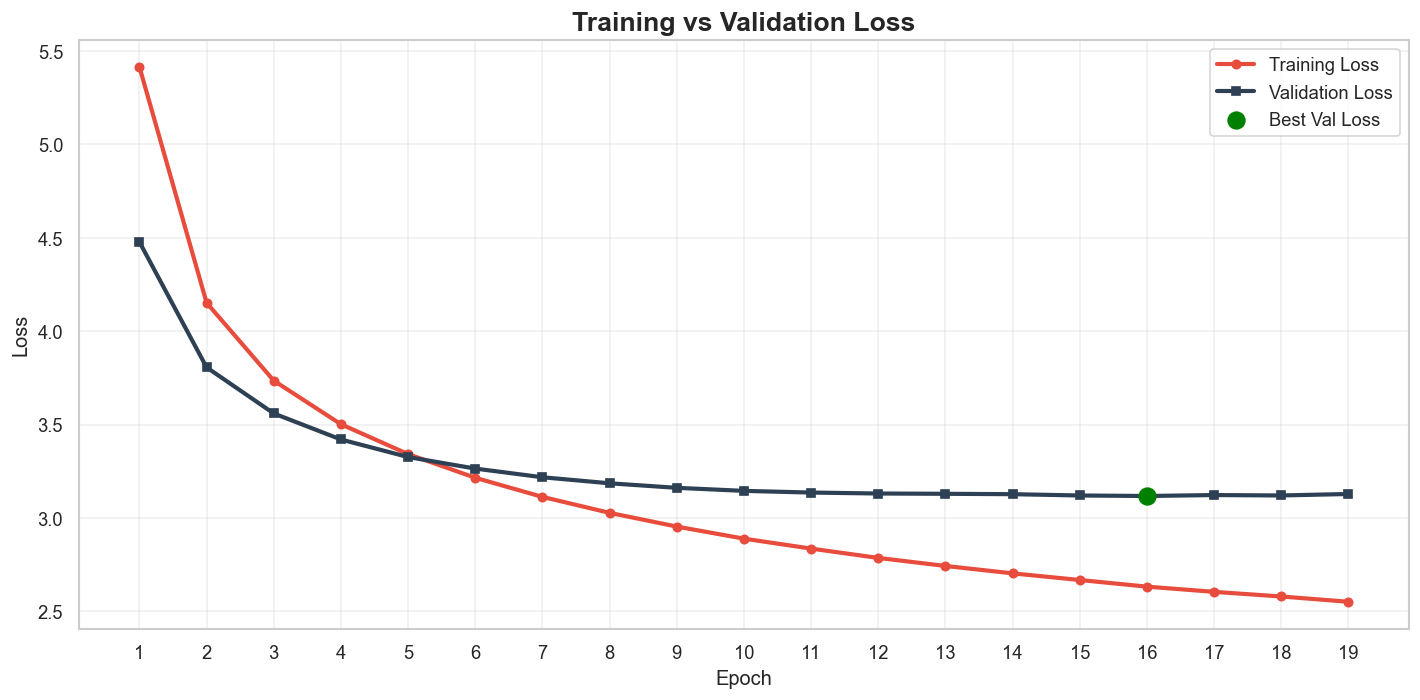

In [65]:
def plot_training_vs_validation_loss(history):
    sns.set_theme(style="whitegrid")
    epochs = range(1, len(history.history['loss']) + 1)
    plt.figure(figsize=(12, 6), dpi=120)

    # Plot lines
    plt.plot(
        epochs,
        history.history['loss'],
        label='Training Loss',
        color='#E74C3C',
        linewidth=2.5,
        marker='o',
        markersize=5
    )

    plt.plot(
        epochs,
        history.history['val_loss'],
        label='Validation Loss',
        color='#2E4053',
        linewidth=2.5,
        marker='s',
        markersize=5
    )

    # Highlight best validation point
    best_epoch = history.history['val_loss'].index(min(history.history['val_loss'])) + 1
    best_val = min(history.history['val_loss'])

    plt.scatter(best_epoch, best_val, color='green', s=100, zorder=5, label='Best Val Loss')

    # Labels and styling
    plt.title('Training vs Validation Loss', fontsize=16, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)

    plt.xticks(epochs)
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_vs_validation_loss(history)

## Beam Search Caption Generator

Generates captions for an image using **beam search decoding**, which keeps multiple candidate sequences to improve prediction quality.

### Parameters
- `image_features`: CNN feature vector for a single image  
- `K_beams`: number of beams (candidate sequences) to keep at each step  
- `log`: whether to use log probabilities for scoring (recommended)

### How it works
1. Starts with the `"start"` token  
2. At each step:
   - Predicts next-word probabilities  
   - Expands each beam with top `K_beams` words  
   - Scores each new sequence  
3. Keeps only the top `K_beams` sequences  
4. Stops early if all beams reach the `"end"` token  
5. Returns the highest-scoring caption  

### Key Idea
Instead of choosing one word at a time (greedy), beam search:
```text
keeps multiple possible captions → explores better sequences → improves results

In [77]:
def beam_search_generator(image_features, K_beams = 3, log = True):
    start_token = tokenizer.word_index['start']
    end_token = tokenizer.word_index['end']
    
    # Each beam is a tuple of (current_sequence, cumulative_log_probability)
    beams = [([start_token], 0.0)]  # Start with the start token and a log probability of 0
    for _ in range(max_caption_length):
        all_candidates = []
        for token_seq, score in beams:
            # If this token sequence already ends with the end token, add it to candidates and skip expansion
            if token_seq[-1] == end_token:
                all_candidates.append((token_seq, score))
                continue
            # Pad current sequence and predict next token probabilities
            padded_seq = pad_sequences([token_seq], maxlen=max_caption_length)
            # Predict the next token probabilities using the model
            predictions = captain_model.predict([image_features.reshape(1, -1), padded_seq], verbose=0)[0]
            # Get the top K token predictions
            top_k_indices = np.argsort(predictions)[-K_beams:]
            for idx in top_k_indices:
                new_seq = token_seq + [idx]
                if log:
                    # small value added to avoid log(0) which is undefined
                    new_score = score + np.log(predictions[idx] + 1e-10)  # Add small value to avoid log(0)
                else:
                    new_score = score * predictions[idx]
                all_candidates.append((new_seq, new_score))
        # Sort all candidates by score and select the top K beams for the next iteration
        beams = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:K_beams]
        # Stop early if all beams end with the end token
        if all(beam[0][-1] == end_token for beam in beams):
            break
    # Return the best sequence (the one with the highest score)
    best_sequence = beams[0][0]

    # Convert token indices back to words
    caption_words = []
    for token in best_sequence:
        if token == start_token:
            continue  # Skip the start token
        if token == end_token:
            break
        word = tokenizer.index_word.get(token, '')
        caption_words.append(word)
    return ' '.join(caption_words)

## BLEU & METEOR Scoring Function

Computes evaluation scores for a single generated caption using:
- BLEU-4
- METEOR

### Parameters
- `actual`: list of ground truth captions (strings)
- `predicted`: generated caption (string)

In [73]:
def bleu_metor_score(actual, predicted):
    smooth = SmoothingFunction().method1
    # actual: list of reference captions
    # predicted: single predicted caption string
    
    # Convert predicted string to list of words
    predicted_tokens = predicted.split()
    
    # Convert actual captions to list of tokenized references
    actual_tokens = [caption.split() for caption in actual]
    
    # corpus_bleu expects: list of references (for one hypothesis), list of hypotheses
    # We have one hypothesis, so wrap it
    score_beam = corpus_bleu([actual_tokens], [predicted_tokens], weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)
    metor_beam = np.mean([meteor_score([ref], predicted_tokens) for ref in actual_tokens])
    
    return {
        "BLEU Score": round(float(score_beam), 5),
        "METEOR Score": round(float(metor_beam), 5)
    }

## Visualization Function

Displays random test images with:
- Ground truth captions
- Beam search generated caption
- Evaluation metrics (BLEU, METEOR)

### Parameters
- `data`: dict mapping `image_id → list of captions`
- `image_features`: dict mapping `image_id → feature vector`
- `beamS_generator`: function to generate captions
- `evaluator`: function to compute evaluation scores
- `num_of_images`: number of images to display

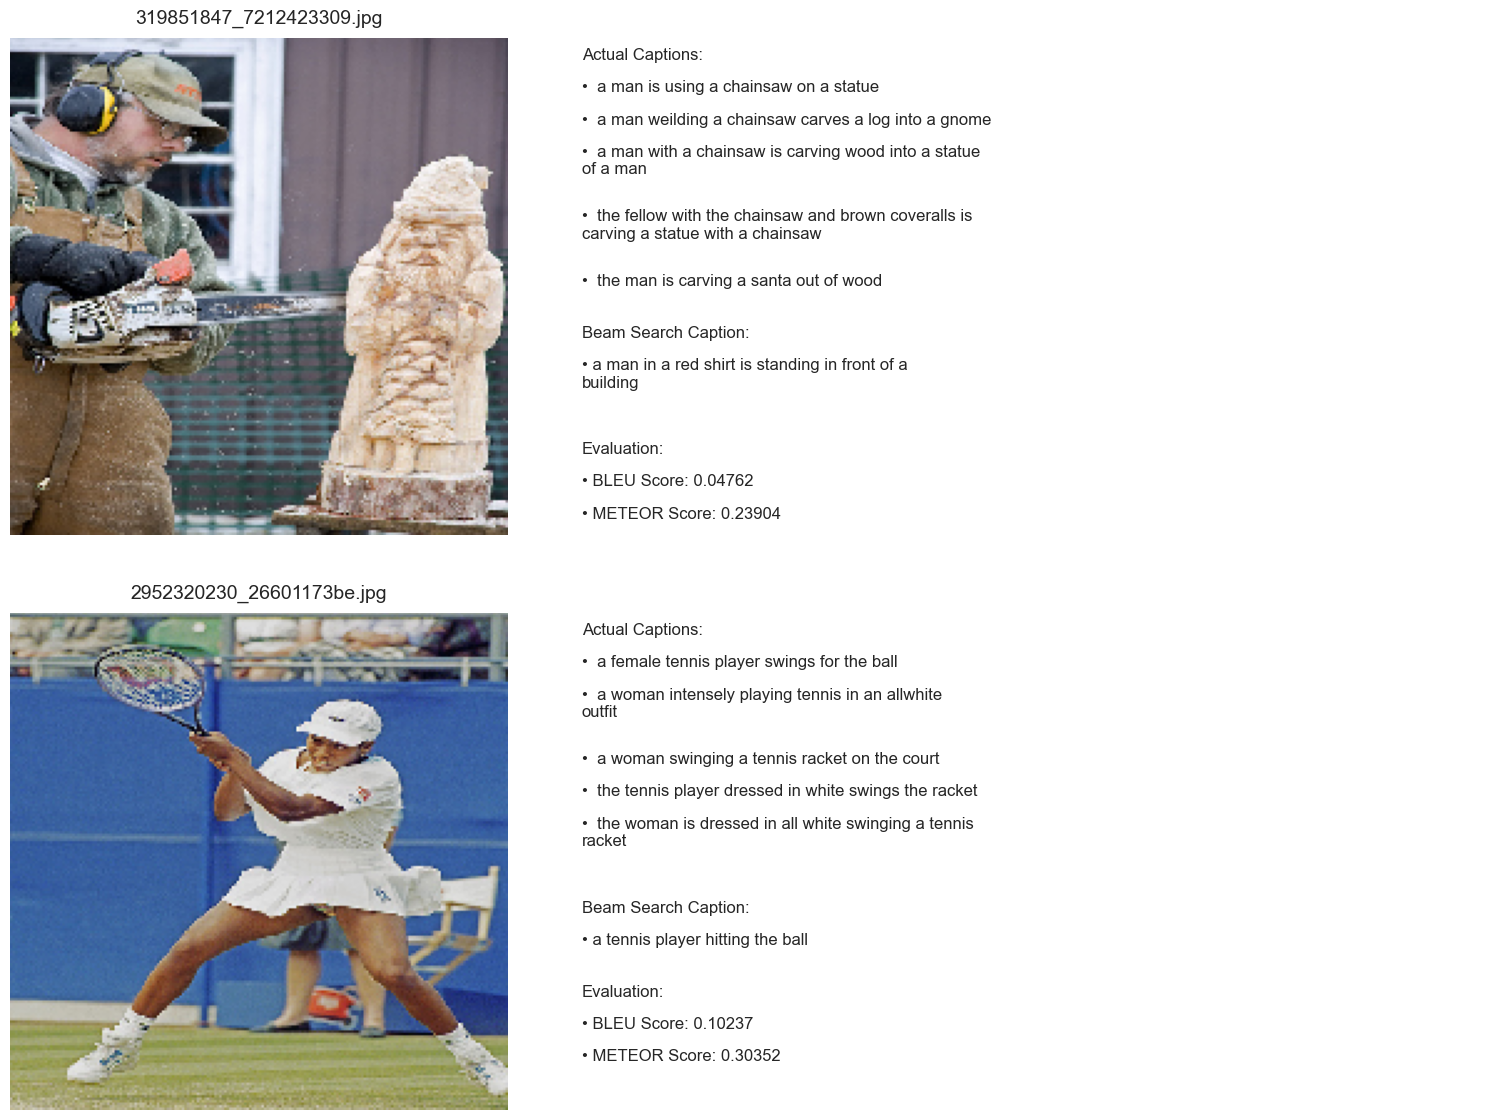

In [78]:
def visualization(data, image_features, beamS_generator, evaluator, num_of_images):
    filenames = list(data.keys())
    selected_images = np.random.choice(filenames, num_of_images, replace=False)
    images_directory = str(BASE_DIR / "archive" / "Images") + os.sep

    fig, axes = plt.subplots(
        num_of_images,
        2,
        figsize=(16, 6 * num_of_images),
        gridspec_kw={'width_ratios': [1, 1.6]}
    )

    # If only one image, axes won't be 2D by default
    if num_of_images == 1:
        axes = np.array([axes])

    for row, filename in enumerate(selected_images):
        actual_cap = data[filename]
        actual_cap = [caption.replace('start', '').replace('end', '') for caption in actual_cap]

        beam_cap = beamS_generator(image_features[filename])
        scores = evaluator(actual_cap, beam_cap)

        # Left axis: image
        ax_img = axes[row, 0]
        image_load = load_img(os.path.join(images_directory, filename), target_size=(200, 200))
        ax_img.imshow(image_load)
        ax_img.axis('off')
        ax_img.set_title(filename, fontsize=14, pad=10)

        # Right axis: text
        ax_text = axes[row, 1]
        ax_text.axis('off')

        lines = []
        lines.append("Actual Captions:")
        for caption in actual_cap:
            wrapped = textwrap.fill(f"• {caption}", width=55)
            lines.append(wrapped)

        lines.append("")
        lines.append("Beam Search Caption:")
        lines.append(textwrap.fill(f"• {beam_cap}", width=55))
        lines.append("")

        if isinstance(scores, dict):
            lines.append("Evaluation:")
            for key, value in scores.items():
                lines.append(f"• {key}: {value}")
        elif isinstance(scores, list):
            lines.append("Evaluation:")
            for item in scores:
                lines.append(textwrap.fill(f"• {str(item)}", width=55))
        else:
            lines.append("Evaluation:")
            lines.append(textwrap.fill(f"• {str(scores)}", width=55))

        # Draw text with better spacing
        y = 0.98
        line_height = 0.065
        for line in lines:
            if line == "":
                y -= line_height * 0.6
            else:
                ax_text.text(
                    0.0, y, line,
                    fontsize=12,
                    va='top',
                    ha='left',
                    wrap=True
                )
                # extra drop for wrapped lines
                wrapped_line_count = line.count("\n") + 1
                y -= line_height * wrapped_line_count

    plt.tight_layout(pad=3.0)
    plt.show()

# Before calling visualization, filter caption_dict to only test images
caption_dict = {}
for caption in captions_IDS:
    image_id, caption_text = caption.split('\t')
    if image_id in test_image_embeddings:  # Only add if in test set
        if image_id not in caption_dict:
            caption_dict[image_id] = []
        caption_dict[image_id].append(caption_text.strip())

visualization(caption_dict, test_image_embeddings, beam_search_generator, bleu_metor_score, 2)

## Evaluation Function (Mean Scores)

Computes average performance of the model over a random sample of test images using:
- BLEU-4
- METEOR

### Parameters
- `image_features`: dict mapping `image_id → feature vector`
- `caption_dict`: dict mapping `image_id → list of captions`
- `beam_search_generator`: function to generate captions
- `n_samples`: number of images to evaluate

In [63]:
def evaluate_mean_scores(
    image_features,
    caption_dict,
    beam_search_generator,
    n_samples=100
):
    smooth = SmoothingFunction().method1

    image_ids = list(image_features.keys())
    n_samples = min(n_samples, len(image_ids))
    sampled_ids = np.random.choice(image_ids, n_samples, replace=False)

    bleu_scores = []
    meteor_scores = []

    for img_id in tqdm(sampled_ids, desc="Evaluating captions"):
        # Clean reference captions
        references = [
            [w for w in cap.replace('start', '').replace('end', '').split()]
            for cap in caption_dict[img_id]
        ]

        # Generate caption
        prediction = beam_search_generator(image_features[img_id])
        candidate = prediction.split()

        # BLEU-4 with smoothing
        bleu = sentence_bleu(
            references,
            candidate,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=smooth
        )

        # METEOR
        meteor = meteor_score(references, candidate)

        bleu_scores.append(bleu)
        meteor_scores.append(meteor)

    return {
        "Mean BLEU-4": round(float(np.mean(bleu_scores)), 5),
        "Mean METEOR": round(float(np.mean(meteor_scores)), 5),
        "Num Samples": n_samples
    }

In [64]:
results = evaluate_mean_scores(
    test_image_embeddings,
    caption_dict,
    beam_search_generator,
    n_samples=len(test_image_embeddings)
)

results

Evaluating captions: 100%|██████████| 810/810 [29:43<00:00,  2.20s/it]


{'Mean BLEU-4': 0.16632, 'Mean METEOR': 0.39222, 'Num Samples': 810}